In [13]:
import PcmPy as pcm
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
import SensoriMotorPrediction.globals as gl
from SensoriMotorPrediction.pcm_models import warp

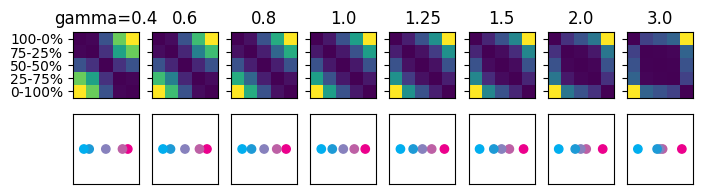

In [14]:
gamma_grid = [0.4, 0.6, 0.8, 1.0, 1.25, 1.5, 2.0, 3.0]
x = [-1, -0.5, 0, 0.5, 1]

fig, axs = plt.subplots(2, len(gamma_grid), figsize=(8, 2), sharey='row', sharex='row')

for g, gamma in enumerate(gamma_grid):
    v = warp(x, gamma)
    G = np.outer(v, v)
    D = pcm.G_to_dist(G)
    ax = axs[0, g]
    ax.imshow(D, vmin=0, vmax=4)
    ax.tick_params(bottom=False, labelbottom=False)
    ax.set_yticks(np.arange(5))
    ax.set_yticklabels(list(gl.regressor_mapping.keys())[:5])
    ax.set_title(f'gamma={gamma}' if g==0 else gamma)
    mds, _ = pcm.classical_mds(G)
    ax = axs[1, g]
    ax.scatter(mds[:, 0], mds[:, 1], color=list(gl.colour_mapping.values())[:5])
    ax.set_xlim(-1.5, 1.5)
    ax.set_ylim(-1, 1)
    ax.tick_params(bottom=False, labelbottom=False, left=False, labelleft=False)

fig.savefig(os.path.join('figures', 'non_linear_expectation_model.pdf'))

plt.show()

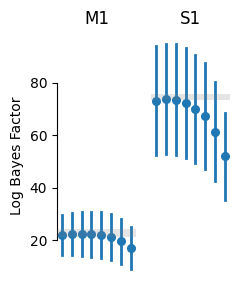

In [15]:
H = 'L'
rois = ['M1', 'S1']

fig, axs = plt.subplots(1, len(rois), sharex=True, sharey=True, figsize=(2.5, 3))

for r, roi in enumerate(rois):
    ax = axs[r]
    plt.sca(ax)
    f = open(os.path.join(gl.baseDir, 'smp2', gl.pcmDir, f'T_cv.warp.glm12.{H}.{roi}.p'), "rb")
    T_cv = pickle.load(f)
    f = open(os.path.join(gl.baseDir, 'smp2', gl.pcmDir, f'T_gr.warp.glm12.{H}.{roi}.p'), "rb")
    T_gr = pickle.load(f)
    pcm.model_plot(T_cv.likelihood,
                    null_model = 'null',
                    noise_ceiling= 'ceil',
                    upper_ceiling = T_gr.likelihood['ceil'],
                    errorbar='se',
                    plottype='point')
    ax.spines[['bottom', 'right', 'left', 'top']].set_visible(False)
    ax.spines['left'].set_visible(True) if r==0 else None
    ax.spines['left'].set_bounds(20, 80)
    ax.tick_params(left=False) if r>0 else None
    ax.tick_params(bottom=False, labelbottom=False)
    ax.set_xticks(axs[r].get_xticks())
    ax.set_xticklabels(gamma_grid)
    ax.set_xlabel('')
    ax.set_title(roi)

fig.tight_layout()

fig.savefig(os.path.join('figures', 'non_linear_expectation_model.BF.pdf'))

plt.show()
